# ¡Hola Rodrigo! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Buen trabajo Rodrigo! Has completado correctamente todo lo necesario del notebook, realizaste un gran trabajo aplicando los conocimientos de analítica necesarios, se nota que los manejas muy bien. No tengo comentarios de corrección obligatorios, pero he dejado algunos comentarios opcionales que ayudarán a complementar tu notebook. De todas formas, tu proyecto está aprobado. Felicitaciones por completar el notebook en la primera revisión, mucho éxito en el siguiente sprint!

Saludos!

</div>

----

PROYECTO SPRINT 6: ANÁLISIS DE DATOS DE PLATAFORMAS DE VIDEOJUEGOS

El propósito de este proyecto es analizar las reseñas, plataformas y datos de ventas de videojuegos correspondientes al año 2016, con el fin de proyectar el comportamiento del mercado en 2017. Este análisis busca orientar las estrategias comerciales, optimizar las campañas de venta y mejorar la planificación del inventario para maximizar el rendimiento de los productos clave.

In [1]:
#Cargo todas las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import factorial
from scipy import stats
from scipy import stats as st

In [2]:
#Cargo el archivo en un DF:
games_data = pd.read_csv("/datasets/games.csv")

Se preparan los datos, es decir, se verifica que los nombres de las columnas esten en minusculas, que cuadren, los dtypes correspondan al tipo de información y se mejora los DF. También se calculan las ventas totales para cada juego y se crea una columna separada para esos valores.

In [3]:
# Se preparan los datos:
# Imprimo la información general/resumida sobre el DF de juegos. Se utiliza .info() para ver los valores de las columnas e identificar los Dtypes para corregir de ser necesario. 
games_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Se aplice el métido .head() para ver las primeras 5 filas y ver si exiten faltas de ortografía/datos que corregir así cómo valores ausentes.
games_data.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
# Se aplica el método srt.lower para que todas las letras de las columnas se vuelva minúscula y también se cambia el formato de año(year of release) a int64
games_data.columns = games_data.columns.str.lower()
games_data["year_of_release"] = games_data["year_of_release"].astype("Int64")
# Se aplicar .head y .info para comprobar los cambios.
games_data.info()
games_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [6]:
# Se aplicar el método fillna para sustituir los valores ausentes, por cada columna un tipo de datos en específico:
#Para critic score y user score se decidió usar 0 ya que valores numericos:
games_data[["critic_score", "user_score", "year_of_release"]] = games_data[["critic_score", "user_score", "year_of_release"]].fillna(0)
#Para name, genre y ratins se decidió usar "desconocido" ya que el dtype es object:
games_data[["name", "genre", "rating"]] = games_data[["name", "genre", "rating"]].fillna("desconocido")
#Se aplica .info para comprobar los cambios al igual que .head
games_data.info()
games_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  Int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  object 
 10  rating           16715 non-null  object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0,desconocido
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0,desconocido


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien hecho con la gestión de los valores ausentes. En los casos donde hay demasiados en una columna, me parece bien dejar los nulos tal como están o reemplazarlos por algún valor identificable. En este caso, para critic_score y user_score, no hay data suficiente para hacer una imputación adecuada y en caso de rellenar con la media o mediana, se introduce un sesgo muy fuerte en la data, por lo que no es adecuado.



</div>

Opté por sustituir los valores NaN a cero para las columnas de critic score, user score y year of release ya que al haber sólo valores numéricos, tenía más sentido eso. Y para las columnas name, genre y rating opté por la palabra desconocido ya que son valores tipo objeto. Los valores ausentes se puede deber a que fueron juegos los cuales no se les puedo calificar por el año que salieron(quizás no había manera de obtener esa información).

In [7]:
#El dtype de user score esta como object, se vetifica si hay datos extraños con value.counts()
games_data["user_score"].value_counts()

0      6701
tbd    2424
7.8     324
8       290
8.2     282
       ... 
0.3       2
0.6       2
0.5       2
9.7       1
0         1
Name: user_score, Length: 97, dtype: int64

Debido a que hay valores con tbd y el dtype es object (cuando debería ser float64) la meor manera es remplazando esto por valores NaN para luego transformar el dtype y por último rellenar con cero esos valores para tener ya DF limpio. 

In [8]:
# Se detectaron 2424 valores tbd y varios valores números como strings. Se remplazan los valores tbd a NaN con el método .replace y después se convierten los valores a float64
games_data["user_score"] = games_data["user_score"].replace("tbd", np.nan)
games_data["user_score"] = games_data["user_score"].astype("float64")
#Luego se sustituyen los valores NaN a 0 con .fillna
games_data["user_score"] = games_data["user_score"].fillna(0)
#Se comprueban los resultados:
games_data.info()
games_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16715 non-null  Int64  
 3   genre            16715 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,desconocido
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,desconocido


In [9]:
# Se calculan las ventas totales por región sumandolas y creando una nueva columna.
games_data["all_region_sales"] = (games_data["na_sales"] + games_data["eu_sales"] + games_data["jp_sales"])
games_data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,all_region_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,74.09
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,desconocido,39.47
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,32.23
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,29.82
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,desconocido,30.38


<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Ok, bien con la idea, pero el cálculo está incompleto, ya que faltó la región other_sales

</div>

Paso 3. Analiza los datos

In [10]:
#Para analizar los datos nos piden mirar cuántos juegos fueron lanzados en diferentes año, por lo que vamos a crear una variable y aplicar el método value counts
games_per_year = games_data["year_of_release"].value_counts().sort_index()
#Se imprime el series:
print(games_per_year)

0        269
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64


In [11]:
#Vamos a mejorar los datos, primero debemos agregar el series al DF:
games_data["games_per_year"] = games_data["year_of_release"].map(games_per_year) # Se agrega con el método .map para que los valores correspondan al año.
#Confirmamos que se vea reflejado: 
games_data.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,all_region_sales,games_per_year
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,74.09,1006
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,desconocido,39.47,14
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,32.23,1427
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,29.82,1426
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,desconocido,30.38,263


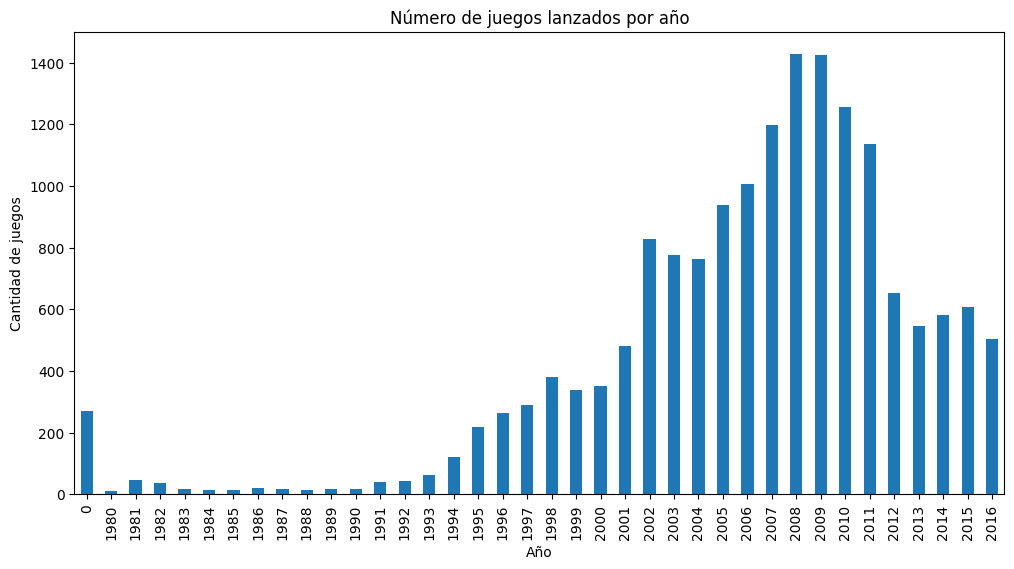

In [12]:
#Realizamos una gráfica comparativa:
plt.figure(figsize=(12, 6))
games_per_year.plot(kind="bar")
plt.title("Número de juegos lanzados por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de juegos")
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     </b> <a class="tocSkip"></a>

Bien, correcto. El gráfico es claro, hubo un peak a fines de los 2000 y luego ha caido a niveles similares a los de inicios del 2000.

</div>

Respondamos a la primera pregunta ¿Son significativos los datos de cada período? 
De acuerdo con games_per_year y la gráfica: En la primera decada de los 80s no hay datos significativos esto se puede deber a que la industria a penas estaba iniciando/tomando relevancia, muy pocas consolas/plataformas.
En la decada de los 90s ya hay datos moderadamente significativos a partir del año 1994 hay 121 juegos, empieza haber un incremento y entre los años 1995-1999 hay entre 219-379 juegos por año por lo que hay suficientes datos para algunos análisis.
Para la primera decada de los 2000s ya hay muchos más datos significativos, siendo los años 2008 y 2009 con mayor pique. Ha sido la decada con mayor crecimiento.
A partir de la segunda decada 2011-2016 empieza haber un declive, posiblemente por cambios dentro la industria pero también debe ser por los 269 juegos sin años publicados.

In [13]:
#Vamos a elegir las plataformas con mayores ventas totales y construir una distribución basada en los datos de cada año, aquí utilizamos el método groupby
platform_sales = games_data.groupby("platform")["all_region_sales"].sum().sort_values(ascending=False)
#Se imprime para ver los resultados:
print(platform_sales)

platform
PS2     1062.33
X360     885.66
Wii      828.44
PS3      803.97
DS       746.86
PS       689.95
GBA      310.12
PS4      265.79
PSP      252.63
XB       249.02
GB       247.26
NES      245.74
3DS      245.64
PC       237.14
N64      214.30
SNES     196.82
GC       193.75
XOne     145.05
2600      96.07
WiiU      76.24
PSV       47.61
SAT       33.52
GEN       29.80
DC        15.68
SCD        1.81
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: all_region_sales, dtype: float64


<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien con la data, pero un gráfico permitiría ver mejor el volumen de ventas de cada plataforma y compararlas rápidamente.

</div>

In [14]:
#Se seleccionan las top 10 plataformas
top_10_platforms = platform_sales.head(10)
print("Top 10 plataformas:")
print(top_10_platforms)

Top 10 plataformas:
platform
PS2     1062.33
X360     885.66
Wii      828.44
PS3      803.97
DS       746.86
PS       689.95
GBA      310.12
PS4      265.79
PSP      252.63
XB       249.02
Name: all_region_sales, dtype: float64


In [15]:
#Se crea una variable para ver la distribución basada en años:
platform_year_evolution = games_data.groupby(['platform', 'year_of_release'])['all_region_sales'].sum()
print(platform_year_evolution.head(10))

platform  year_of_release
2600      0                  10.43
          1980               11.26
          1981               35.36
          1982               28.57
          1983                5.78
          1984                0.27
          1985                0.45
          1986                0.67
          1987                1.93
          1988                0.73
Name: all_region_sales, dtype: float64


In [16]:
#Para calcular correctamente los rangos de los años se emprimen los años disponibles, tomando los rangos de los 2000s y se aplica para cada plataforma:
#Ejemplo:
print("Años disponibles para X360:")
print(platform_year_evolution.loc["X360"].index)
# Se realiza la misma accción para los top 10.

Años disponibles para X360:
Index([0, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016],
      dtype='object', name='year_of_release')


In [17]:
# Ahora sí, se crea un diccionario para tener las plataformas en una sola variable:
top_10_evolution = {
    "PS2": platform_year_evolution.loc["PS2"].loc[2000:2010],
    "X360": platform_year_evolution.loc["X360"].loc[2005:2016], 
    "Wii": platform_year_evolution.loc["Wii"].loc[2006:2016],
    "PS3": platform_year_evolution.loc["PS3"].loc[2006:2016],
    "DS": platform_year_evolution.loc["DS"].loc[2004:2013],
    "PS": platform_year_evolution.loc["PS"].loc[2000:2003],
    "GBA": platform_year_evolution.loc["GBA"].loc[2000:2007],
    "PS4": platform_year_evolution.loc["PS4"].loc[2013:2016],
    "PSP": platform_year_evolution.loc["PSP"].loc[2004:2015],
    "XB": platform_year_evolution.loc["XB"].loc[2000:2008]}
    
print("Evoluciones de las top 10 plataformas agrupadas:")
for platform, evolution in top_10_evolution.items():
    print(f"\n{platform}:")
    print(evolution)

Evoluciones de las top 10 plataformas agrupadas:

PS2:
year_of_release
2000     35.59
2001    149.65
2002    183.66
2003    163.62
2004    171.96
2005    141.51
2006     89.18
2007     52.30
2008     34.59
2009     16.24
2010      4.44
Name: all_region_sales, dtype: float64

X360:
year_of_release
2005      7.61
2006     47.20
2007     86.68
2008    122.56
2009    109.26
2010    155.80
2011    131.11
2012     91.45
2013     80.82
2014     31.61
2015     10.86
2016      1.40
Name: all_region_sales, dtype: float64

Wii:
year_of_release
2006    123.63
2007    139.22
2008    156.33
2009    189.43
2010    117.73
2011     54.37
2012     20.22
2013      7.87
2014      3.45
2015      1.05
2016      0.17
Name: all_region_sales, dtype: float64

PS3:
year_of_release
2006     17.30
2007     62.48
2008    101.78
2009    113.08
2010    121.36
2011    135.22
2012     90.87
2013     95.85
2014     40.88
2015     14.70
2016      3.23
Name: all_region_sales, dtype: float64

DS:
year_of_release
2004     1

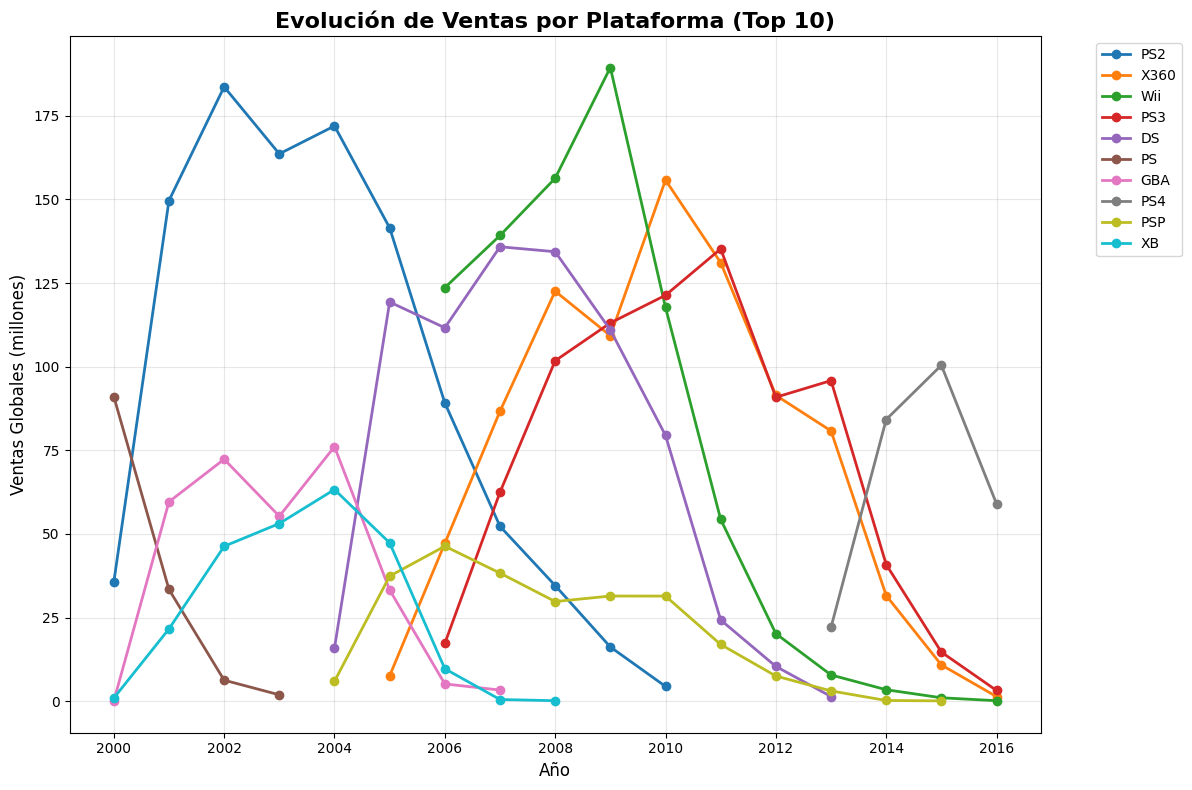

In [18]:
# Se crea una gráfica de líneas ya que son 10 plataformas visualmente el de líneas tendrá más sentido.
plt.figure(figsize=(12, 8))
#Plotear cada plataforma
for platform, evolution in top_10_evolution.items():
    plt.plot(evolution.index, evolution.values, marker="o", label=platform, linewidth=2)
    
plt.title("Evolución de Ventas por Plataforma (Top 10)", fontsize=16, fontweight="bold")
plt.xlabel("Año", fontsize=12)
plt.ylabel("Ventas Globales (millones)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy buen gráfico, permite apreciar el periodo de vida de cada consola, incluyendo su auge y luego caída.

</div>

Para poder desarrollar la gráfica de líneas se tomaron en cuenta las 10 plataformas con mayor venta durante la duración de estas.
Se eligieron 10 y no 5 para tener un panoráma más amplio de la evolución de consumo y cómo estas pasaron de ser populares a obsoletas. 
Ahora sí, respondamos las siguientes preguntas, ¿Cuánto tardan generalmente en aparecer las nuevas plataformas y las antiguas en desaparecer? R= Las nuevas plataformas tardan aproximadamente de 2 a 3 años en alcanzar su pico de ventas después de su lanzamiento, y una vez que alcanzan este pico, la caída es bastante abrupta, tardando de 3 a 5 años en volverse obsoletas.
¿Qué plataformas son lideres en ventas? R= Las plataformas líderes de acuerdo con la gráfica son Wii, Ps2, X360, DS y Ps3 lo que las convierten en las más rentables.
¿Cuáles creecen y cuáles se reducen? R= Todas estas plataformas ya tuvieron su crecimiento máximo, y ahora están en caída debido a que hay nuevas plataformas que están tomando su lugar cómo el Xone, Ps4 y el Wiiu que están arrancando aún. 

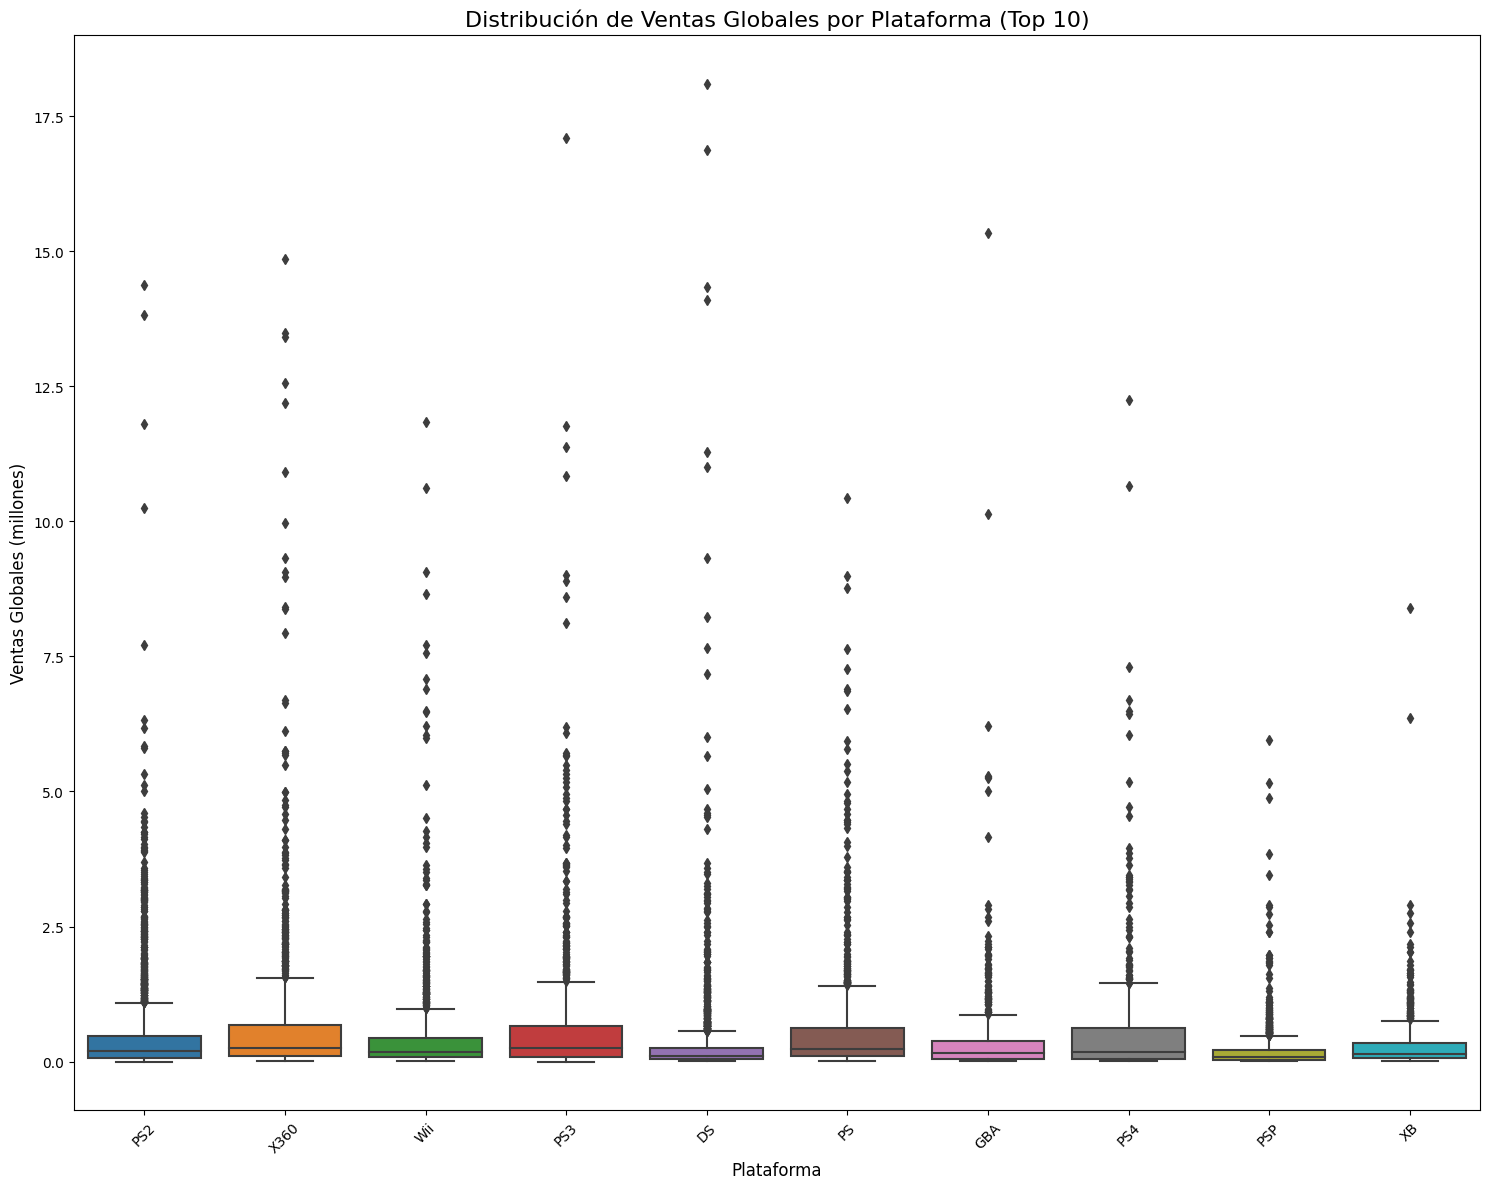

In [19]:
#Se crea un diagrama de caja
plt.figure(figsize=(15, 12))
top_platforms_list = top_10_platforms.index.tolist()
df_filtered = games_data[games_data["platform"].isin(top_platforms_list)]
#Para que la tabla se pueda apreciar visualmente se limítan los valors atípicos:
df_filtered_clean = df_filtered[df_filtered["all_region_sales"] <= 20]
# Crear boxplot
sns.boxplot(data=df_filtered_clean, x="platform", y="all_region_sales", 
            order=top_platforms_list)
plt.title("Distribución de Ventas Globales por Plataforma (Top 10)", fontsize=16)
plt.xlabel("Plataforma", fontsize=12)
plt.ylabel("Ventas Globales (millones)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien con el gráfico de boxplots, sin embargo, nota que a causa de los outliers no podemos ver la variabilidad de cada consola (las cajas son muy pequeñitas). En este caso se puede realizar el mismo gráfico pero reemplazando la escala normal por una escala logarítmica o agregando un gráfico adicional con la escala normal pero limitada a valores más pequeños (una especie de zoom al gráfico original).

</div>

In [20]:
# Se calcula la media y la varianza, así como los valores mínimos, máximos y el conteo:
platform_stats = df_filtered.groupby("platform")["all_region_sales"].agg([
    "mean", "median", "std", "min", "max", "count"]).round(2)
print(platform_stats)

          mean  median   std   min    max  count
platform                                        
DS        0.35    0.10  1.30  0.01  26.92   2151
GBA       0.38    0.16  0.87  0.01  15.34    822
PS        0.58    0.24  1.00  0.01  10.43   1197
PS2       0.49    0.20  0.93  0.00  14.37   2161
PS3       0.60    0.25  1.17  0.00  17.09   1331
PS4       0.68    0.17  1.36  0.01  12.25    392
PSP       0.21    0.08  0.43  0.01   5.95   1209
Wii       0.63    0.18  2.83  0.01  74.09   1320
X360      0.70    0.25  1.47  0.01  20.13   1262
XB        0.30    0.14  0.52  0.01   8.40    824


¿Qué sucede con las ventas promedio en varias plataformas? 
De acuerdo con la información estadísdtica; 
1. Plataformas con mejores ventas promedio
- X360 (0.70) y PS4 (0.68) tienen las mejores ventas promedio.
- PSP (0.21) tiene las ventas promedio más bajas.

2. Variabilidad extrema en Wii;
- std = 2.83 es muy elevada.
- max = 74.09 (Wii Sports - el juego más vendido).
- Esto significa que Wii tiene algunos "mega-hits" pero muchos juegos con ventas bajas.

3. Consistencia en las ventas;
- PSP y XB tienen baja variabilidad (std = 0.43 y 0.52).
- PS3 y X360 son más consistentes que Wii.

4. Volumen de juegos;
- DS y PS2 tienen más de 2,000 juegos cada una.
- PS4 solo tiene 392 juegos (plataforma más nueva). 

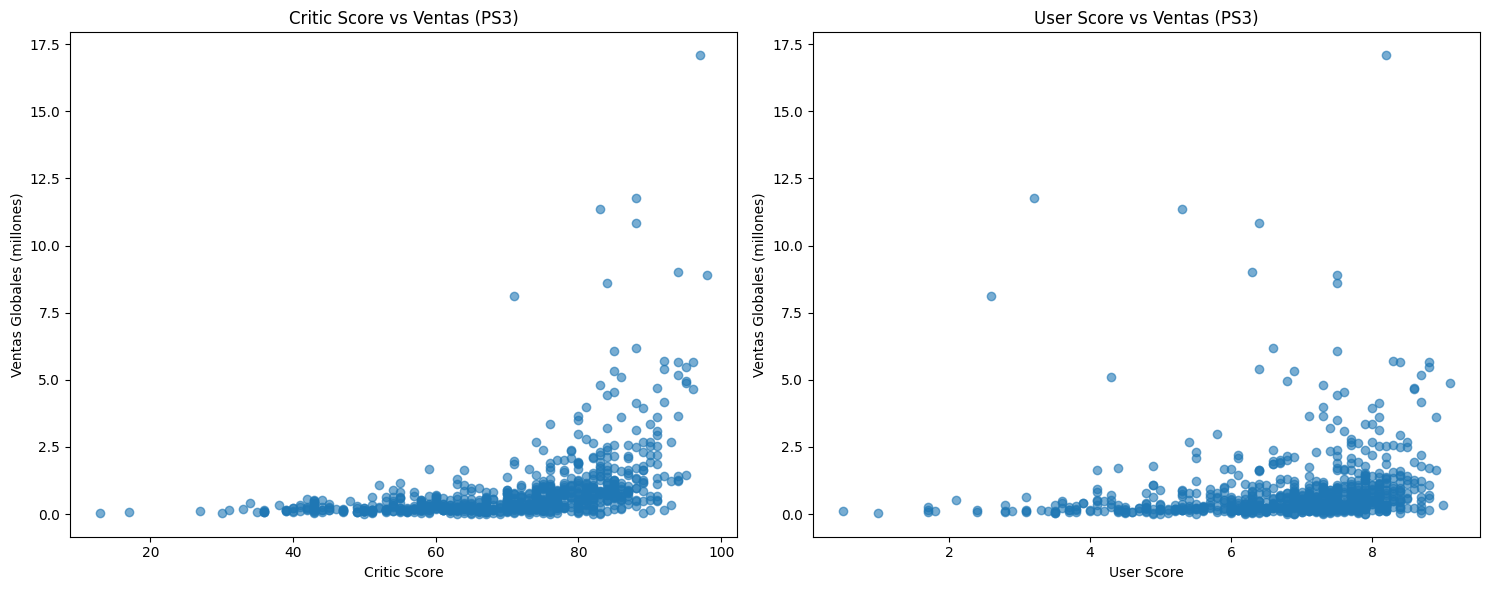

Correlación Critic Score - Ventas: 0.433
Correlación User Score - Ventas: 0.146


In [21]:
#Se crea gráfico de dispersión para ver cómo las reseñas de usuarios afectan las ventas de una plataforma.
# Se selecciona el Ps3 por tener datos consistentes. 
ps3_data = games_data[games_data["platform"] == "PS3"].copy()

# Eliminar juegos sin reseñas (score = 0)
ps3_filtered = ps3_data[(ps3_data["critic_score"] > 0) & 
                        (ps3_data["user_score"] > 0)]

# Crear gráfico de dispersión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Critic Score vs Ventas
ax1.scatter(ps3_filtered["critic_score"], ps3_filtered["all_region_sales"], alpha=0.6)
ax1.set_xlabel("Critic Score")
ax1.set_ylabel("Ventas Globales (millones)")
ax1.set_title("Critic Score vs Ventas (PS3)")

# User Score vs Ventas
ax2.scatter(ps3_filtered["user_score"], ps3_filtered["all_region_sales"], alpha=0.6)
ax2.set_xlabel("User Score")
ax2.set_ylabel("Ventas Globales (millones)")
ax2.set_title("User Score vs Ventas (PS3)")

plt.tight_layout()
plt.show()

# Calcular correlaciones
critic_corr = ps3_filtered["critic_score"].corr(ps3_filtered["all_region_sales"])
user_corr = ps3_filtered["user_score"].corr(ps3_filtered["all_region_sales"])

print(f"Correlación Critic Score - Ventas: {critic_corr:.3f}")
print(f"Correlación User Score - Ventas: {user_corr:.3f}")

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el gráfico y el cálculo del coeficiente. Permite obtener una visión general de la correlación entre ambas variables.

</div>

Conclusión: Tomando en cuenta que +1 (correlación perfecta positiva), 0 (sin correlación lineal, y -1 ( correlación perfecta negativa); para critic score hay una correlación moderada positiva, lo que indica que  cuando las puntuaciones de los críticos suben, las ventas tienden a subir también, es decir, los críticos sí influyen en el éxito comercial, pero no es único factor, también el marketing, la plataforma (pupular), el género del video juego pueden ser más determinandtes. 
Para user score, el puntuaje tiene una correlación debil positiva, lo que indica que esta no influye en las ventas que pueda tener el video juego, ya que los jugadores califícan después de comprar, no antes. La clave para mejorar als ventas es invertir para obtener buenas reseñas por parte de críticos puede ser rentable (sobre todo si son influencers), pero no depender sólo en las puntuaciones para predecir las ventas. Cabe destacar que depende mucho del género del juego, si esta es más "family friendly" o si es para un "publico" en específico. En definitiva contruir un "hype" antes del estreno es clave. 

In [22]:
# De acueardo con las conclusiones, se comparan las ventas de los mismos juegos en otras plataformas.
# Encontrar juegos que aparecen en múltiples plataformas
games_multiplatform = games_data.groupby("name")["platform"].nunique() # Se aplica el método unique() para ver cuáles son estos juegos
games_with_multiple_platforms = games_multiplatform[games_multiplatform > 1] # Se filtra >1 para que nos arroje los juegos que aparezcan más de 1 vez.
games_with_multiple_platforms.head()

name
 Frozen: Olaf's Quest               2
007: Quantum of Solace              6
007: The World is not Enough        2
11eyes: CrossOver                   2
18 Wheeler: American Pro Trucker    2
Name: platform, dtype: int64

In [23]:
#Se toma de ejemplo los juegos que están disponibles en más platformas:
games_example = ["007: Quantum of Solace", "Frozen: Olaf's Quest ", "007: The World is not Enough",
                "11eyes: CrossOver", "18 Wheeler: American Pro Trucker"]
games_platforms = games_data[games_data["name"].isin(games_example)]
print(games_platforms[["name", "platform", "all_region_sales"]].sort_values("all_region_sales", ascending=False))

                                   name platform  all_region_sales
1204       007: The World is not Enough      N64              1.53
1285             007: Quantum of Solace     X360              1.34
1785             007: Quantum of Solace      PS3              0.96
2243       007: The World is not Enough       PS              0.86
3120             007: Quantum of Solace      Wii              0.58
4805   18 Wheeler: American Pro Trucker      PS2              0.35
4475             007: Quantum of Solace      PS2              0.17
9507             007: Quantum of Solace       DS              0.12
10076  18 Wheeler: American Pro Trucker       GC              0.11
14658            007: Quantum of Solace       PC              0.02
15091                 11eyes: CrossOver     X360              0.02
15656                 11eyes: CrossOver      PSP              0.02


<div class="alert alert-block alert-warning">
<b>Comentario de Revisor              </b><a class="tocSkip"></a>

Bien con la comparación de los valores, pero lo ideal hubiese sido presentar esto en un gráfico.



</div>

De acuerdo con los resultados, N64 tiene el juego con más ventas en una sola plataforma "007: The World is not Enough", incluso más que PS. Se popularizó para la consola debido al año de lanzamiento. El segundo video juego con más ventas total y con presencian en más plataformas es "007: Quantum of Solace", destacando en la plataforma X360 seguido por PS3. Las plataformas de nueva generación o más recientes son las que dominan en ventas, puede deberse a la calidad de los gráficos y jugabilidad. Posiblemente X360 superó en ventas a PS3 debido a la popularidad de la plataforma (valor de la plataforma/juego). Los juegos de acción tienen a ser más populares además de que el juego está basado en un franquicia de películas lo que hace que sea más interesante. 

In [24]:
# Se analisa la distribución por género aplicando el método value counts:
genre_distribution = games_data['genre'].value_counts()
# Ventas por genero:
genre_sales = games_data.groupby('genre')['all_region_sales'].agg(['sum', 'mean', 'count']).sort_values("sum", ascending=False)
print(genre_distribution)
print(genre_sales)

Action          3369
Sports          2348
Misc            1750
Role-Playing    1498
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       873
Fighting         849
Strategy         683
Puzzle           580
desconocido        2
Name: genre, dtype: int64
                  sum      mean  count
genre                                 
Action        1559.57  0.462918   3369
Sports        1196.76  0.509693   2348
Shooter        948.34  0.716810   1323
Role-Playing   874.93  0.584065   1498
Platform       776.68  0.874640    888
Misc           728.12  0.416069   1750
Racing         652.57  0.522474   1249
Fighting       411.17  0.484299    849
Simulation     359.24  0.411501    873
Puzzle         230.19  0.396879    580
Adventure      221.10  0.169685   1303
Strategy       163.38  0.239209    683
desconocido      2.34  1.170000      2


<div class="alert alert-block alert-success">
<b>Comentario de Revisor      </b> <a class="tocSkip"></a>

Muy bien con el análisis, es importante revisar tanto las ventas totales como la venta promedio. Eso si, hubiese sido mejor mostrar esto con un par de gráficos.



</div>

El genero de acción es más polular (número de juegos), la adrenalidad que causa es adictiva para el consumidor. Seguido por el de deportes (número de juegos), no solo es un genero popular en la TV tambien permite al consumidor sentir que está experimentando el practicar su deporte favorito. Y cómo tercer luegar tenemos "misc" que son todos los juegos que no tienen una categoría definida y puede tener un poco de todo. Los generos más rentables por ventas totales son "action", "sports" y "Shooter". Los juegos más rentables por genero individual son "platform", "shooter" y "racing" que cuenta con las medias(promedio) más elevadas. Esto debido a que está iniciando la popularidad de juegar en línea. 

Paso 4. Crea un perfil de usuario para cada región

In [25]:
#Calcular ventas totales por plataforma en cada región:
total_sales_platform_na = games_data.groupby("platform")["na_sales"].sum().reset_index()
total_sales_platform_eu = games_data.groupby("platform")["eu_sales"].sum().reset_index()
total_sales_platform_jp = games_data.groupby("platform")["jp_sales"].sum().reset_index()
#Identificar el top 5 de plataformas para NA, EU y JP ordenando de mayor a menor:
top_platforms_na = total_sales_platform_na.sort_values("na_sales", ascending=False)
top_platforms_eu = total_sales_platform_eu.sort_values("eu_sales", ascending=False)
top_platforms_jp = total_sales_platform_jp.sort_values("jp_sales", ascending=False)

In [26]:
# Obtener top 5 plataformas por región:
top_5_na = top_platforms_na.head().copy()
top_5_eu = top_platforms_eu.head().copy()
top_5_jp = top_platforms_jp.head().copy()
print("Top 5 plataformas en Norteamérica:")
print(top_5_na)
print("\nTop 5 plataformas en Europa:")
print(top_5_eu)
print("\nTop 5 plataformas en Japón:")
print(top_5_jp)

Top 5 plataformas en Norteamérica:
   platform  na_sales
28     X360    602.47
16      PS2    583.84
26      Wii    496.90
17      PS3    393.49
4        DS    382.40

Top 5 plataformas en Europa:
   platform  eu_sales
16      PS2    339.29
17      PS3    330.29
28     X360    270.76
26      Wii    262.21
15       PS    213.61

Top 5 plataformas en Japón:
   platform  jp_sales
4        DS    175.57
15       PS    139.82
16      PS2    139.20
23     SNES    116.55
2       3DS    100.67


In [27]:
#Se calcula ventas totales por región
total_na = games_data["na_sales"].sum()
total_eu = games_data["eu_sales"].sum()
total_jp = games_data["jp_sales"].sum()
#Se calcula porcentajes de cuota por mercado
top_5_na["market_share"] = (top_5_na["na_sales"] / total_na * 100).round(2)
top_5_eu["market_share"] = (top_5_eu["eu_sales"] / total_eu * 100).round(2)
top_5_jp["market_share"] = (top_5_jp["jp_sales"] / total_jp * 100).round(2)
#Se imprimen los resultados
print(top_5_na)
print(top_5_eu)
print(top_5_jp)
#Identifica patrones y diferencias

   platform  na_sales  market_share
28     X360    602.47         13.69
16      PS2    583.84         13.26
26      Wii    496.90         11.29
17      PS3    393.49          8.94
4        DS    382.40          8.69
   platform  eu_sales  market_share
16      PS2    339.29         13.99
17      PS3    330.29         13.62
28     X360    270.76         11.17
26      Wii    262.21         10.81
15       PS    213.61          8.81
   platform  jp_sales  market_share
4        DS    175.57         13.53
15       PS    139.82         10.78
16      PS2    139.20         10.73
23     SNES    116.55          8.98
2       3DS    100.67          7.76


In [28]:
#Se aplica el método var() para cada una de las regiones:
# Varianza de las cuotas dentro de cada región
na_variance = top_5_na['market_share'].var()
eu_variance = top_5_eu['market_share'].var()
jp_variance = top_5_jp['market_share'].var()
print("Nortamerica var value:")
print(na_variance)
print("Europe var value:")
print(eu_variance)
print("Japan var value:")
print(jp_variance)

Nortamerica var value:
5.46403
Europe var value:
4.588399999999998
Japan var value:
4.756629999999999


De acuerdo con los resultados NA tiene la mayor varianza lo que indica que hay más desigualdad entras cuotras de mercado con las plataformas principales, por ejemplo: X360 domina con un 13.69%, hay diferencia considerable con esta plataform y las demás, el mercado es menos equilibrado. En contraste EU tiene la menor varianza, esto indica una cuota de mercado más equilibrada, (PS2 y PS3) es decir, la competencia entre plataformas es más pareja, un mercado más distribuido. Japón se posiciona en medio de estas 2 regiones, con una situación intermedia. Es se puede deber a multiples factores cómo posicionamiento de las plataformas por región, poder adquisitivo, y plataforma favorita, preferencias culturales (producto local).

In [29]:
# Calcular ventas totales por género en cada región
genre_sales_na = games_data.groupby("genre")["na_sales"].sum().reset_index()
genre_sales_eu = games_data.groupby("genre")["eu_sales"].sum().reset_index()
genre_sales_jp = games_data.groupby("genre")["jp_sales"].sum().reset_index()

# Ordenar de mayor a menor para obtener el top 5
top_genres_na = genre_sales_na.sort_values("na_sales", ascending=False).head()
top_genres_eu = genre_sales_eu.sort_values("eu_sales", ascending=False).head()
top_genres_jp = genre_sales_jp.sort_values("jp_sales", ascending=False).head()

In [30]:
# Calcular ventas totales por región
total_na_genre = games_data["na_sales"].sum()
total_eu_genre = games_data["eu_sales"].sum()
total_jp_genre = games_data["jp_sales"].sum()

# Calcular porcentajes de cuota de mercado
top_genres_na["market_share"] = (top_genres_na["na_sales"] / total_na_genre * 100).round(2)
top_genres_eu["market_share"] = (top_genres_eu["eu_sales"] / total_eu_genre * 100).round(2)
top_genres_jp["market_share"] = (top_genres_jp["jp_sales"] / total_jp_genre * 100).round(2)
print(top_genres_na)
print(top_genres_eu)
print(top_genres_jp)

       genre  na_sales  market_share
0     Action    879.01         19.97
10    Sports    684.43         15.55
8    Shooter    592.24         13.45
4   Platform    445.50         10.12
3       Misc    407.27          9.25
      genre  eu_sales  market_share
0    Action    519.13         21.41
10   Sports    376.79         15.54
8   Shooter    317.34         13.09
6    Racing    236.51          9.75
3      Misc    212.74          8.77
           genre  jp_sales  market_share
7   Role-Playing    355.41         27.39
0         Action    161.43         12.44
10        Sports    135.54         10.45
4       Platform    130.83         10.08
3           Misc    108.11          8.33


In [31]:
#Se aplica el método var() para cada una de las regiones:
na_genre_variance = top_genres_na['market_share'].var()
eu_genre_variance = top_genres_eu['market_share'].var()
jp_genre_variance = top_genres_jp['market_share'].var()
print("Nortamerica var value:")
print(na_genre_variance)
print("Europe var value:")
print(eu_genre_variance)
print("Japan var value:")
print(jp_genre_variance)

Nortamerica var value:
18.85292
Europe var value:
25.77712
Japan var value:
60.375070000000015


De acuardo con los resultados, NA tiene gustos más equilibrados al tener menor varianza (18.85), los generos principales tienen cuatas de mercado más similares entre sí, no hay un genero que domine excesivamente el mercado y está mejos distribuido. En cambio Japón tiene preferencias muy concentradas (60.38), existe mucha desigualdad entre los géneros principales, hay generos cómo el role-playing que domina fuertemente el mercado hacinedo que la preferencia se concentre en cierto tipohs de juegos, es un mercado menos equilibrado en término de generos. Y por último tenemos a Europa con una varianza de(25.78), ay cierta concentración en algunos géneros, pero no extrema, existe un quilibrio intermedio entre diversidad y concentración con patrones de consumo moderadamente variados. Estos datos se dan ya que cada región tiene fuertemente inculcada una cultura y en cada una hay multiples backgrounds (deversidad multicultural) mientras que otras son más isoladas en preferencias.

In [32]:
#Vamos a verificar si las clasificaciones de ESRB afectana  als ventas en regiones ondividuales:
# Crear un DataFrame para analizar ESRB por región
esrb_analysis = games_data.groupby('rating').agg({
    'na_sales': 'sum',
    'eu_sales': 'sum', 
    'jp_sales': 'sum',
    'all_region_sales': 'sum'
}).reset_index()

# Ver las clasificaciones disponibles
print("Clasificaciones ESRB disponibles:")
print(esrb_analysis.sort_values("all_region_sales", ascending=False))

Clasificaciones ESRB disponibles:
        rating  na_sales  eu_sales  jp_sales  all_region_sales
8  desconocido   1242.46    613.83    841.96           2698.25
1            E   1292.99    710.25    198.11           2201.35
7            T    759.75    427.03    151.40           1338.18
5            M    748.48    483.97     64.24           1296.69
2         E10+    353.32    188.52     40.20            582.04
4          K-A      2.56      0.27      1.46              4.29
0           AO      1.26      0.61      0.00              1.87
3           EC      1.53      0.11      0.00              1.64
6           RP      0.00      0.08      0.00              0.08


In [33]:
# Calcular porcentajes de cuota de mercado por clasificación ESRB
esrb_analysis['na_market_share'] = (esrb_analysis['na_sales'] / total_na * 100).round(2)
esrb_analysis['eu_market_share'] = (esrb_analysis['eu_sales'] / total_eu * 100).round(2)
esrb_analysis['jp_market_share'] = (esrb_analysis['jp_sales'] / total_jp * 100).round(2)

print("Cuotas de mercado por clasificación ESRB:")
print(esrb_analysis.sort_values("all_region_sales", ascending=False))

Cuotas de mercado por clasificación ESRB:
        rating  na_sales  eu_sales  jp_sales  all_region_sales  \
8  desconocido   1242.46    613.83    841.96           2698.25   
1            E   1292.99    710.25    198.11           2201.35   
7            T    759.75    427.03    151.40           1338.18   
5            M    748.48    483.97     64.24           1296.69   
2         E10+    353.32    188.52     40.20            582.04   
4          K-A      2.56      0.27      1.46              4.29   
0           AO      1.26      0.61      0.00              1.87   
3           EC      1.53      0.11      0.00              1.64   
6           RP      0.00      0.08      0.00              0.08   

   na_market_share  eu_market_share  jp_market_share  
8            28.22            25.32            64.90  
1            29.37            29.29            15.27  
7            17.26            17.61            11.67  
5            17.00            19.96             4.95  
2             8.03    

Conclusiones: Los juegos familiares "E"(everyone-juegos familiares)tienen cuotas muy similares para los mercados de NA(29.37) y EU(29.29) respectivamente, es decir, en estas regiones prefieren más juegos familiares, en cambio en JP(15.27) mucho menor.
Los juegos "M" (mature-juegos para adultos) destaca EU(19.96 con la taza más alta), NA(17) y JP(4.95) la taza más baja, esto quiere decir que EU es más tolerante para los juegos para adultos (menos censura, menos conservador).
Los juegos "T" (teen- jeugos para adolecentes) se encuentran más equilibrados NA(17.26), EU(17.61) y JP(11.67).
La sorpresa son los juegos con rating desconocido dónde JP(64.90) destaca dejando por atrás a NA(28.22) y EU(25.32), esto se debe a que Japon usa otro sistema de calificación, adicional qeu muchos juegos japoneses nunca recibieron clasificación ESRB, además prefieren consumir productos locales, más adoc a sus preferencias. Aquí hay muchas implicaciones culturales dónde regiones cómo NA está más regulados por ESRB mientra que en JP es más independiente al sistema ESRB, diferentes estádares sobre qué contenido es apropiado para ciertas edades. 

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, muy bien con la comparación entre las regiones. Es importante revisar diferentes dimensiones entre cada uno, esto revela puntos importantes de segmentación que podrían ser beneficiosos para un modelo de predicción. Por ejemplo, observamos que Japón es muy diferente respecto a las otras regiones en varios aspectos, tal vez esto justifique diferentes modelos o reglas para esta región.
    
</div>

Paso 5. Prueba las siguientes hipótesis

Formulación de hipótesis sobre la calificación promedio de los usuarios para las plataformasxbos one y PC son las mismas:
Hipótesis nula: Las calificaciones promedio entre ambas plataformas son iguales
Hipótesis alternativa: Las calificaciones promedio entre ambas plataformas son diferentes

In [34]:
# Primeo separo la calificación promedio de los usuarios por plataform xone y pc:
xone_data = games_data[(games_data["platform"] == "XOne") & (games_data["user_score"] > 0)]
pc_data = games_data[(games_data["platform"] == "PC") & (games_data["user_score"] > 0)]

# Extraer las calificaciones de usuarios
xone_scores = xone_data["user_score"]
pc_scores = pc_data["user_score"]

print(f"Xbox One - Muestra: {len(xone_scores)} juegos")
print(f"PC - Muestra: {len(pc_scores)} juegos")
print(f"Xbox One - Media: {xone_scores.mean():.2f}")
print(f"PC - Media: {pc_scores.mean():.2f}")

Xbox One - Muestra: 182 juegos
PC - Muestra: 770 juegos
Xbox One - Media: 6.52
PC - Media: 7.06


In [35]:
# Se aplica la prueba de Levene:
stat_levene, p_levene = stats.levene(xone_scores, pc_scores)
print(f"Estadístico de Levene: {stat_levene:.4f}")
print(f"P-valor Levene: {p_levene:.4f}")

# Interpretar resultado
alpha = 0.05
if p_levene > alpha:
    print("Las varianzas son homogéneas (usar equal_var=True)")
    equal_var = True
else:
    print("Las varianzas NO son homogéneas (usar equal_var=False)")
    equal_var = False

Estadístico de Levene: 1.2213
P-valor Levene: 0.2694
Las varianzas son homogéneas (usar equal_var=True)


In [36]:
# Se escoge la prueba estadística para comparar las medias de dos planos independientes: prueba t de Student (prueba t de dos muestras)
# Valor alpha será 0.05
alpha = 0.05
xone_data
pc_data

t_stat, p_valor = stats.ttest_ind(xone_scores, pc_scores, equal_var=True)
print("El estadistico t calculado es:", t_stat)
print("El p-valor de la prueba es:", p_valor)

El estadistico t calculado es: -4.368333815003015
El p-valor de la prueba es: 1.3896435533548819e-05


Conclusiones: El estadístico t calculado dar un valor de -4.368, este valor negativo indica que la media de Xone es menor que la media de PC. El p-valor es muy pequeño, menor que el valor de significancia (alpha), esto significa que hay evidencia muy fuerte para rechazar la hipótesis nula ya que las calificaciones promedio no son iguales, y se acepta la hipótesis alternativa: las calificaciones promedio entre ambas plataformas son diferentes.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con los tests, fueron realizados de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es *estadísticamente diferente*. En futuros notebooks podrías utilizar este test para decidir sobre la igualdad de varianzas. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).

</div>

Paso 6. Escribe una conclusión general

Conclusión general del análisis de videojuegos (2016)

El análisis evidenció una evolución clara en el mercado de videojuegos a lo largo del tiempo. Desde los años noventa, la industria experimentó un crecimiento acelerado que alcanzó su punto máximo entre 2008 y 2009, con más de 1,400 lanzamientos anuales. No obstante, a partir de 2011 se observa una tendencia decreciente, posiblemente relacionada con la consolidación del mercado, una mayor inversión en títulos de alta calidad y, sobre todo, la transición hacia nuevas generaciones de consolas y plataformas.

En cuanto al análisis regional, se identificaron diferencias marcadas en las preferencias y estructuras de mercado:

Norteamérica presentó la mayor desigualdad (varianza: 5.46), con Xbox 360 liderando el mercado (13.69% de cuota). Esto sugiere una fuerte inclinación hacia el desarrollo local y una concentración en pocas plataformas dominantes.

Europa mostró un mercado más equilibrado (varianza: 4.59), con PS2 y PS3 en posiciones similares. La competencia se distribuye principalmente entre las consolas de Sony (PS, PS2, PS3, PS4) y Microsoft (Xbox 360, Xbox One).

Japón se ubicó en un punto intermedio (varianza: 4.76), con una clara preferencia por productos locales como Nintendo DS (13.53%). Destaca el predominio de consolas portátiles y una fuerte influencia cultural en la elección de géneros, particularmente el Role-Playing.

Asimismo, las diferencias culturales se reflejan en los géneros más populares y en el impacto de las calificaciones ESRB:

Norteamérica mostró gustos equilibrados entre Action (19.97%) y Sports (15.55%).

Europa presentó una distribución similar, aunque con mayor aceptación hacia contenidos de tipo Mature.

Japón, en cambio, concentró su preferencia en Role-Playing (27.39%), reafirmando sus rasgos culturales distintivos.

Por último, las pruebas estadísticas revelaron que los críticos ejercen una influencia moderada sobre las ventas (correlación: 0.433), mientras que las calificaciones de los usuarios —emitidas generalmente después de la compra— tienen un impacto limitado (correlación: 0.146). En conjunto, los resultados sugieren que el marketing y la expectativa previa al lanzamiento son factores más determinantes en el éxito comercial que las reseñas posteriores.

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con estas conclusiones. Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos. Haces muy bien al incluir las métricas más importantes, tus afirmaciones se ven apoyadas en algo objetivo.   

    
</div>